<a href="https://colab.research.google.com/github/min0left-hub/mobis_ai_education_2026/blob/main/DL_04_A_MNIST_AUTOENCODER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## import library

In [2]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model



## MNIST DATA LOAD

In [3]:
# data load
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# normalization
x_train = x_train.astype(np.float32) / 255.
x_test = x_test.astype(np.float32) / 255.

# flatten
x_train_flatten = x_train.reshape((x_train.shape[0], -1))
x_test_flatten = x_test.reshape((x_test.shape[0], -1))

print(x_train_flatten.shape)
print(x_test_flatten.shape)
print(y_train.shape)
print(y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)
(60000,)
(10000,)


In [4]:
# data load
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
# normalization
x_train = x_train.astype(np.float32)/255.
x_test = x_test.astype(np.float32)/255.
# flatten
x_train_flatten = x_train.reshape((x_train.shape[0], -1))
x_test_flatten = x_test.reshape((x_test.shape[0], -1))

print(x_train_flatten.shape)
print(x_test_flatten.shape)

(60000, 784)
(10000, 784)


## AE model architecture

In [17]:
# encoding dimension
encoding_dim = 32

input_img = Input(shape=(784,)) # 28*28
encoded = Dense(encoding_dim, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

# autoencoder
autoencoder = Model(input_img, decoded)

# encoder
encoder = Model(input_img, encoded)

# decoder
encoded_input = Input(shape=(encoding_dim,))
decoded_layer = autoencoder.layers[-1]
decoder = Model(encoded_input, decoded_layer(encoded_input))

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


## MODEL FIT

In [18]:
autoencoder.fit(x_train_flatten, x_train_flatten,
                batch_size=256, epochs=50,
                validation_data=(x_test_flatten,x_test_flatten))


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.2766 - val_loss: 0.1887
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1702 - val_loss: 0.1538
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1447 - val_loss: 0.1345
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1292 - val_loss: 0.1218
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1183 - val_loss: 0.1129
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1109 - val_loss: 0.1069
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1061 - val_loss: 0.1029
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1026 - val_loss: 0.0999
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0999 - val_loss: 0.0976
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0979 - val_loss: 0.0958
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0965 - val_loss: 0.0946
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

## PREDICTION

In [19]:
encoded_imgs = encoder.predict(x_test_flatten)
decoded_imgs = decoder.predict(encoded_imgs)
# for testing decoded_imgs matched valid_imgs
valid_imgs = autoencoder.predict(x_test_flatten)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


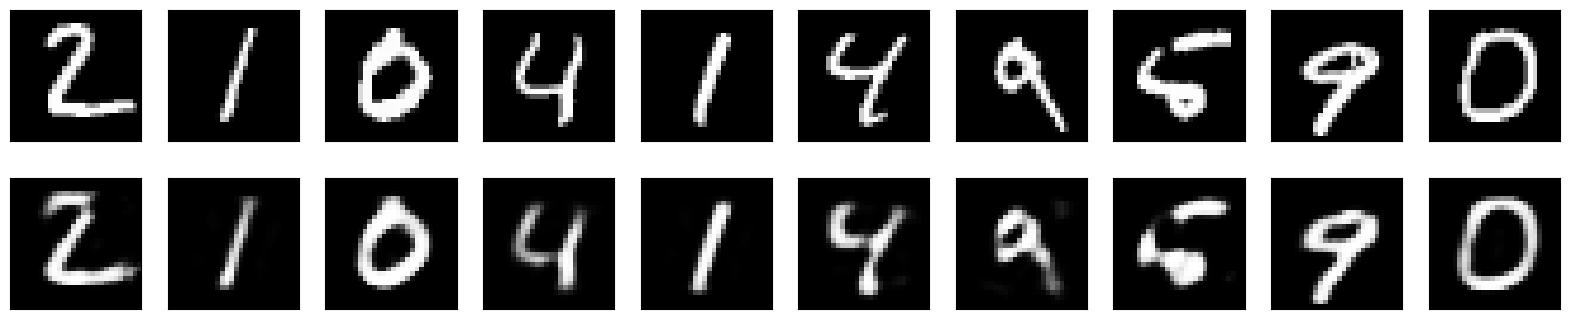

In [20]:
import matplotlib.pyplot as plt

n = 10  # 이미지 갯수
plt.figure(figsize=(20, 4))
for i in range(1, n+1):
    # 원본 데이터
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test_flatten[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # 재구성된 데이터
    ax = plt.subplot(2, n, i + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


## PCA

In [21]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# encoder를 이용해서 test data를 latent vector로 변환
encoded_imgs = encoder.predict(x_test_flatten)

print("Encoded shape:", encoded_imgs.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Encoded shape: (10000, 32)


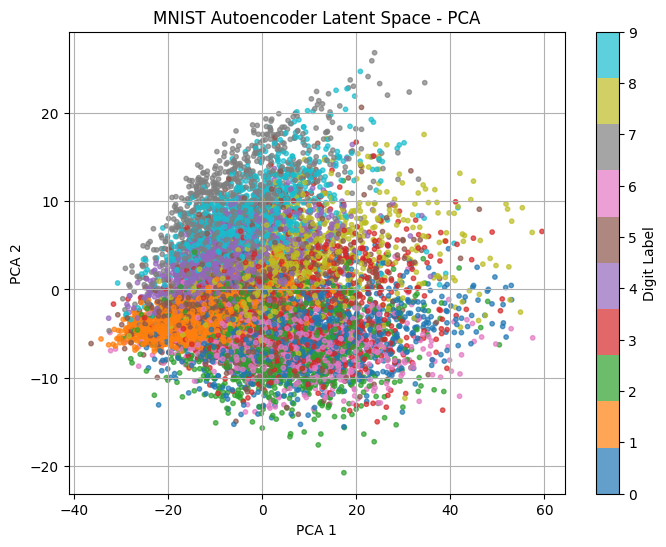

In [22]:
# latent vector를 2D로 축소
pca = PCA(n_components=2)
encoded_2d_pca = pca.fit_transform(encoded_imgs)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    encoded_2d_pca[:, 0],
    encoded_2d_pca[:, 1],
    c=y_test,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.colorbar(scatter, ticks=range(10), label="Digit Label")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("MNIST Autoencoder Latent Space - PCA")
plt.grid(True)
plt.show()

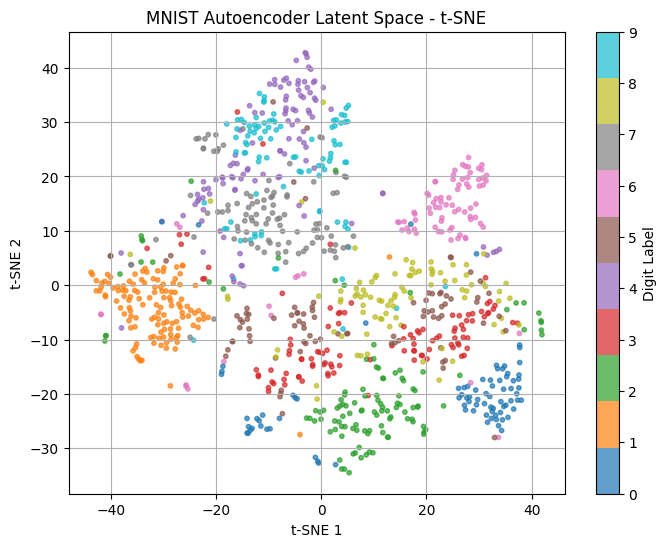

In [27]:
# 너무 많으면 오래 걸리니까 일부만 사용
num_samples = 1000

encoded_sample = encoded_imgs[:num_samples]
label_sample = y_test[:num_samples]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

encoded_2d_tsne = tsne.fit_transform(encoded_sample)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    encoded_2d_tsne[:, 0],
    encoded_2d_tsne[:, 1],
    c=label_sample,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.colorbar(scatter, ticks=range(10), label="Digit Label")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("MNIST Autoencoder Latent Space - t-SNE")
plt.grid(True)
plt.show()

In [5]:
x_train = x_train.reshape((-1,28,28,1))
x_test = x_test.reshape((-1,28,28,1))
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


## convolutional auto encoder

## SET MODEL ARCHITRCTURE

In [6]:
input_img = Input(shape=(28, 28, 1))  # 'channels_firtst'이미지 데이터 형식을 사용하는 경우 이를 적용

x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# encoder의 shape = (samples, 4, 4, 8)

x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation='relu')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# decoder의 shape = (sampels, 28, 28, 1)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

encoder = Model(input_img, encoded)

decoded_input = Input(shape=(4,4,8))
decoded_layer = autoencoder.layers[7](decoded_input)
for i in range(8,len(autoencoder.layers)):
    decoded_layer = autoencoder.layers[i](decoded_layer)
decoder = Model(decoded_input, decoded_layer)


## MODEL FIT

In [7]:
from tensorflow.keras.callbacks import TensorBoard
autoencoder.fit(x_train, x_train,
                batch_size=256, epochs=50,
                validation_data=(x_test,x_test),
                callbacks=[TensorBoard(log_dir='/tmp/autoencoder')])

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - loss: 0.2829 - val_loss: 0.1720
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1558 - val_loss: 0.1419
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1357 - val_loss: 0.1290
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1264 - val_loss: 0.1231
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1211 - val_loss: 0.1178
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1173 - val_loss: 0.1148
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1146 - val_loss: 0.1122
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1124 - val_loss: 0.1103
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1106 - val_loss: 0.1094
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1093 - val_loss: 0.1079
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1081 - val_loss: 0.1063
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/st

## PREDICTION

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


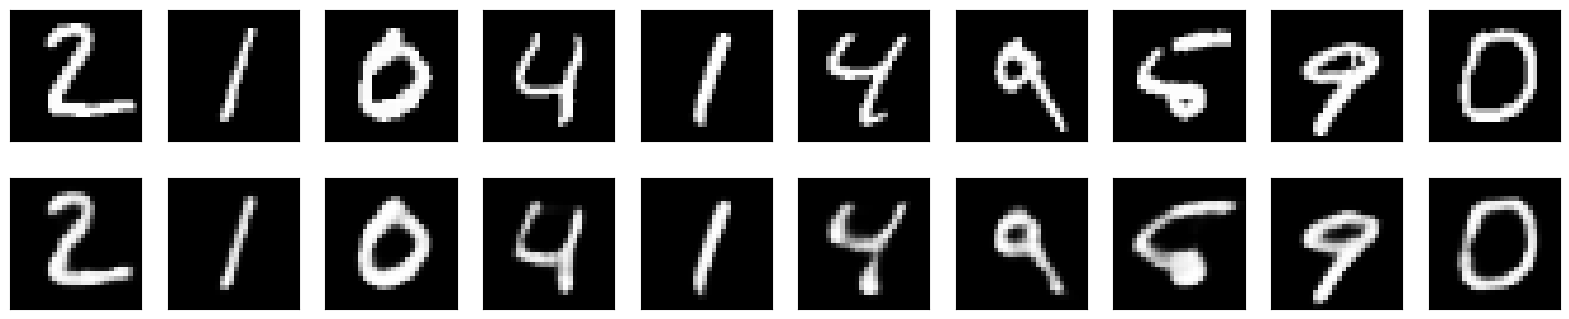

In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

n = 10  # 이미지 갯수
plt.figure(figsize=(20, 4))
for i in range(1, n+1):
    # 원본 데이터
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test_flatten[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # 재구성된 데이터
    ax = plt.subplot(2, n, i + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## encoded data

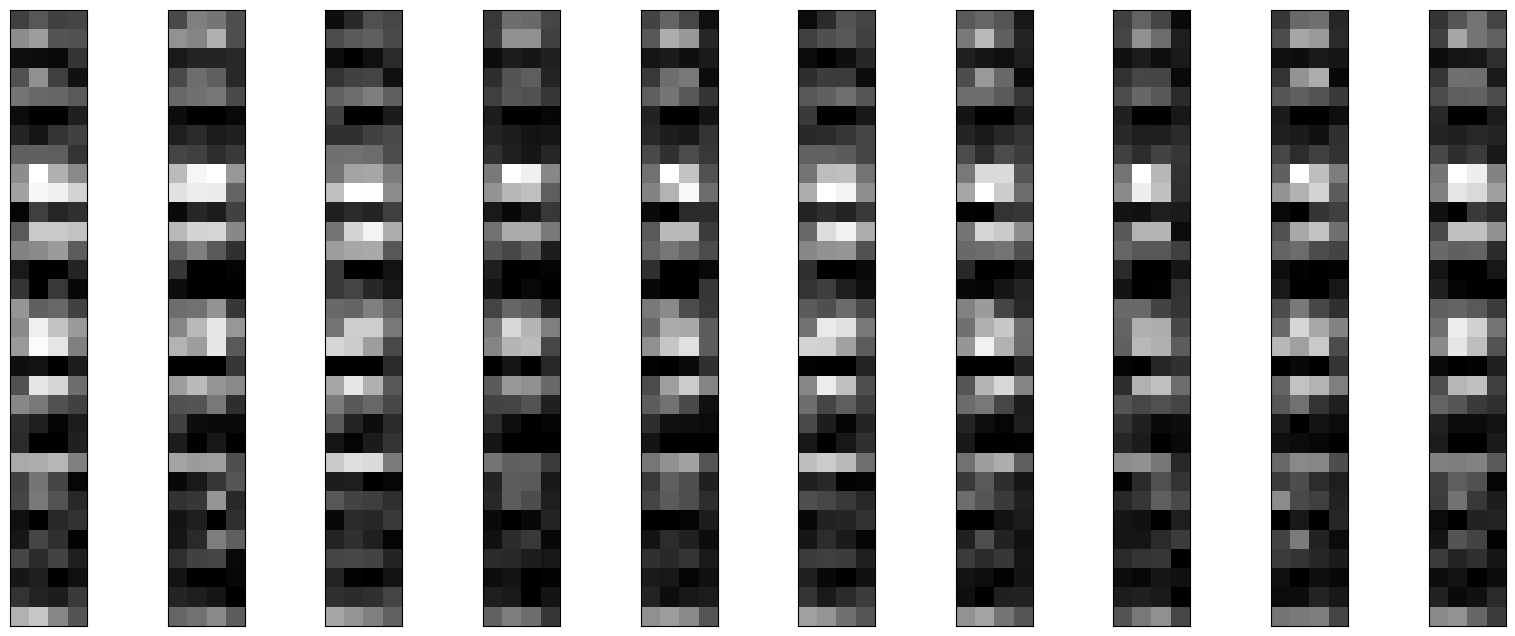

In [11]:
n = 10
plt.figure(figsize=(20, 8))
for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(encoded_imgs[i].reshape(4, 4 * 8).T)
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## PCA


In [12]:
# CNN autoencoder용 x_test shape 확인
print("x_test shape:", x_test.shape)

# encoder로 latent representation 추출
encoded_imgs = encoder.predict(x_test)

print("Encoded shape before flatten:", encoded_imgs.shape)

# (N, 4, 4, 8) → (N, 128)
encoded_imgs_flatten = encoded_imgs.reshape(encoded_imgs.shape[0], -1)

print("Encoded shape after flatten:", encoded_imgs_flatten.shape)

x_test shape: (10000, 28, 28, 1)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Encoded shape before flatten: (10000, 4, 4, 8)
Encoded shape after flatten: (10000, 128)


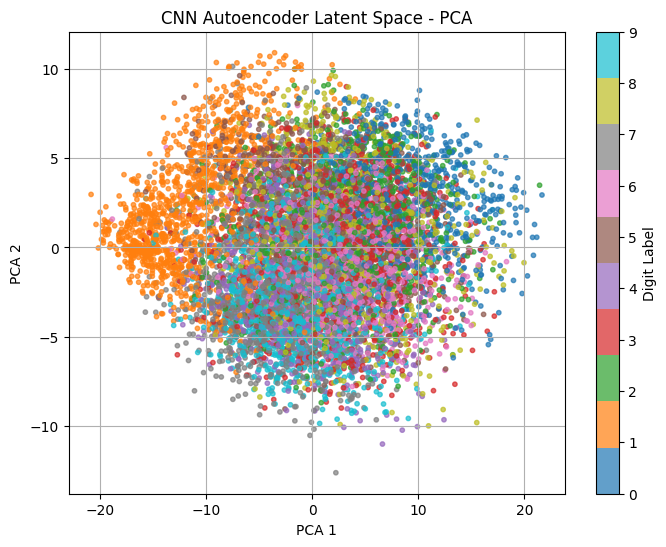

In [13]:
pca = PCA(n_components=2)
encoded_2d_pca = pca.fit_transform(encoded_imgs_flatten)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    encoded_2d_pca[:, 0],
    encoded_2d_pca[:, 1],
    c=y_test,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.colorbar(scatter, ticks=range(10), label="Digit Label")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("CNN Autoencoder Latent Space - PCA")
plt.grid(True)
plt.show()

## t-SNE 시각화

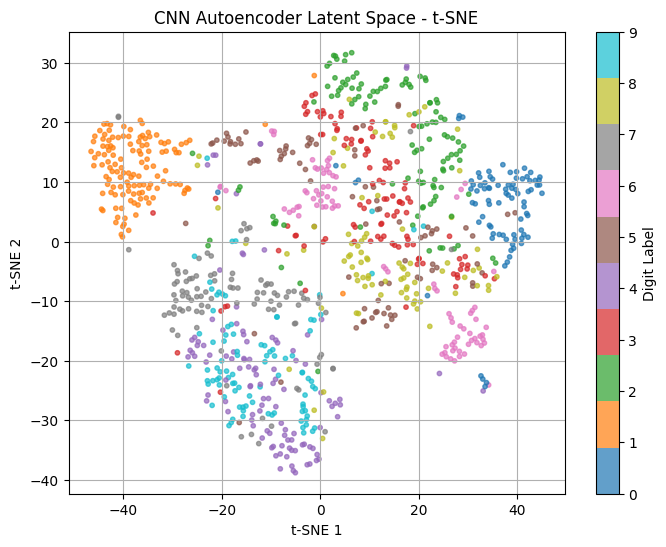

In [15]:
num_samples = 1000

encoded_sample = encoded_imgs_flatten[:num_samples]
label_sample = y_test[:num_samples]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

encoded_2d_tsne = tsne.fit_transform(encoded_sample)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    encoded_2d_tsne[:, 0],
    encoded_2d_tsne[:, 1],
    c=label_sample,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.colorbar(scatter, ticks=range(10), label="Digit Label")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("CNN Autoencoder Latent Space - t-SNE")
plt.grid(True)
plt.show()

## legend 추가

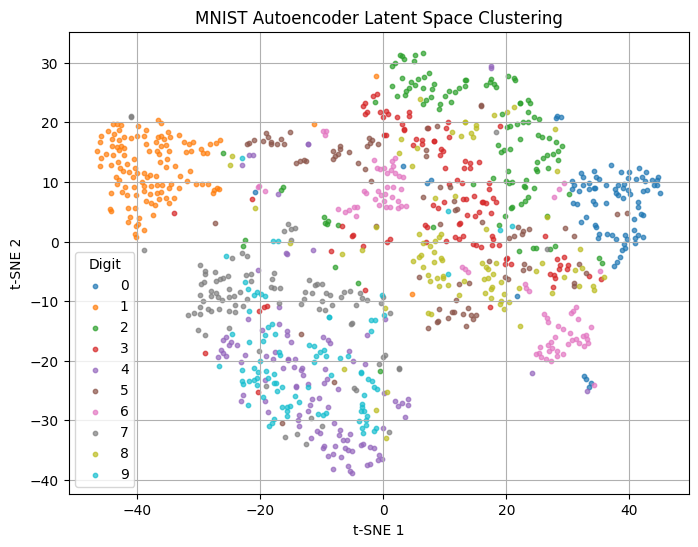

In [16]:
plt.figure(figsize=(8, 6))

for digit in range(10):
    idx = label_sample == digit

    plt.scatter(
        encoded_2d_tsne[idx, 0],
        encoded_2d_tsne[idx, 1],
        s=10,
        alpha=0.7,
        label=str(digit)
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("MNIST Autoencoder Latent Space Clustering")
plt.legend(title="Digit")
plt.grid(True)
plt.show()

## KMeans clustering
label없이 latent vector만 보고 10개 군집으로 분류

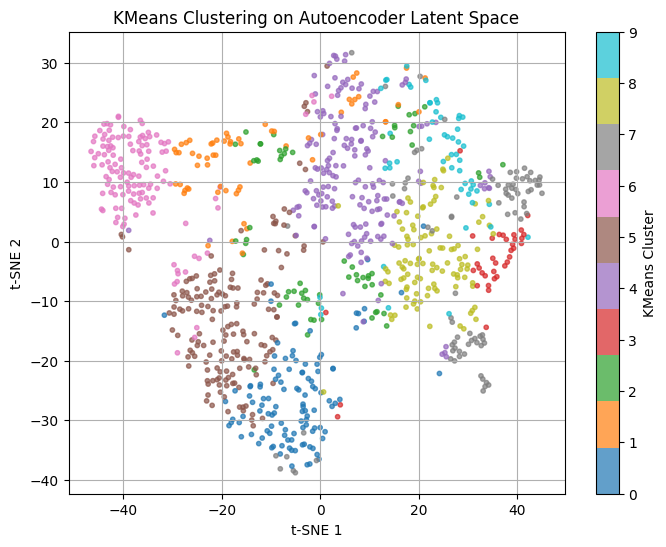

In [17]:
from sklearn.cluster import KMeans

num_clusters = 10

kmeans = KMeans(
    n_clusters=num_clusters,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(encoded_imgs_flatten)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    encoded_2d_tsne[:, 0],
    encoded_2d_tsne[:, 1],
    c=cluster_labels[:num_samples],
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.colorbar(scatter, ticks=range(10), label="KMeans Cluster")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("KMeans Clustering on Autoencoder Latent Space")
plt.grid(True)
plt.show()